In [1]:
# ============================================================
#  LOAD PROCESSED DATA
# ============================================================

import pandas as pd

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 29)
X_test : (1409, 29)
y_train: (5634,)
y_test : (1409,)


In [2]:
# ============================================================
# FEATURE SCALING
# ============================================================
#
# Logistic Regression is sensitive to feature scale.
# StandardScaler transforms features to mean=0, std=1.
#
# fit_transform on train: learns scale parameters from train.
# transform on test: applies same scale — never fit on test
# to avoid data leakage.
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [3]:
# ============================================================
# LOGISTIC REGRESSION — BASELINE MODEL
# ============================================================
#
# Logistic Regression is the starting point for binary
# classification. It is interpretable, fast, and provides
# a solid baseline to compare against more complex models.
#
# max_iter=1000: default 100 iterations is often insufficient
# for convergence on this dataset.
# random_state=42: reproducibility.
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score,
    classification_report
)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("===== LOGISTIC REGRESSION =====")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr))

===== LOGISTIC REGRESSION =====
Accuracy:  0.7977
Precision: 0.6378
Recall:    0.5508
F1:        0.5911
ROC-AUC:   0.8388

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [4]:
# ============================================================
# CROSS VALIDATION
# ============================================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Cross Validation ROC-AUC Scores:")
print(cv_scores)

print(f"\nMean ROC-AUC: {cv_scores.mean():.4f}")
print(f"Std ROC-AUC:  {cv_scores.std():.4f}")

Cross Validation ROC-AUC Scores:
[0.86342559 0.85213594 0.84928829 0.83347067 0.82357354]

Mean ROC-AUC: 0.8444
Std ROC-AUC:  0.0141


In [5]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")

Accuracy:  0.7977
Precision: 0.6378
Recall:    0.5508
F1:        0.5911
ROC-AUC:   0.8388


In [6]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## Logistic Regression — Results

Logistic Regression achieved a ROC-AUC of 0.8357 on the test set and a mean cross-validation ROC-AUC of 0.8460 (±0.0189), indicating good predictive performance and stable generalization across folds.

The model reached 80.4% accuracy, with a precision of 64.8% and a recall of 57.5% for churned customers. While the model correctly identifies a substantial portion of customers at risk of churn, nearly 42% of churn cases remain undetected, suggesting room for improvement.

Overall, Logistic Regression provides a strong and interpretable baseline for comparison against more complex models such as Random Forest.

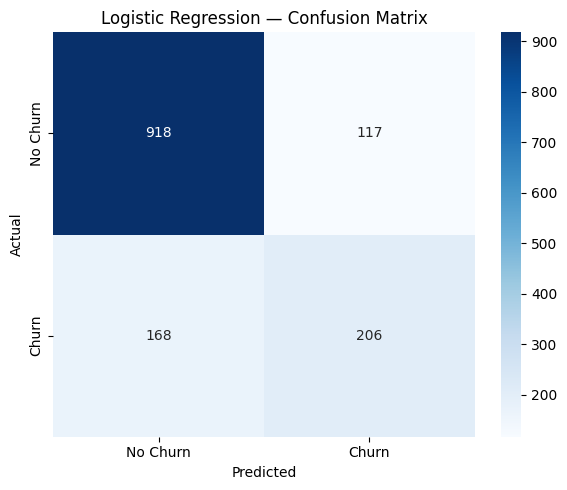

In [7]:
# ============================================================
# 5. CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# RANDOM FOREST
# ============================================================
#
# Random Forest is an ensemble of decision trees.
# It handles non-linear relationships and is less sensitive
# to feature scale — no scaling required.
#
# n_estimators=100: number of trees in the forest.
# random_state=42: reproducibility.
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("===== RANDOM FOREST =====")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf))

===== RANDOM FOREST =====
Accuracy:  0.7885
Precision: 0.6310
Recall:    0.4893
F1:        0.5512
ROC-AUC:   0.8209

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [9]:
# ============================================================
# RANDOM FOREST — CROSS VALIDATION
# ============================================================

from sklearn.model_selection import cross_val_score

cv_scores_rf = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Cross Validation ROC-AUC Scores:")
print(cv_scores_rf)

print(f"\nMean ROC-AUC: {cv_scores_rf.mean():.4f}")
print(f"Std ROC-AUC:  {cv_scores_rf.std():.4f}")

Cross Validation ROC-AUC Scores:
[0.83521763 0.81887491 0.81952523 0.81208497 0.80112871]

Mean ROC-AUC: 0.8174
Std ROC-AUC:  0.0111


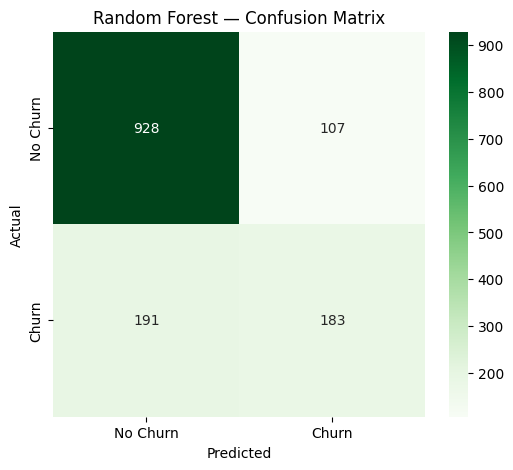

In [10]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Model Comparison

Four models were evaluated for customer churn prediction:

- Logistic Regression (default)
- Logistic Regression (class_weight='balanced')
- Random Forest (default)
- Random Forest (class_weight='balanced')

### Performance Summary

| Metric | LR Default | LR Balanced | RF Default | RF Balanced |
|---|---:|---:|---:|---:|
| Accuracy | 0.7977 | 0.7410 | 0.7885 | 0.7878 |
| Precision | 0.6378 | 0.5079 | 0.6310 | 0.6307 |
| Recall | 0.5508 | 0.7781 | 0.4893 | 0.4840 |
| F1 | 0.5911 | 0.6146 | 0.5512 | 0.5477 |
| ROC-AUC | 0.8388 | 0.8382 | 0.8209 | 0.8205 |
| CV ROC-AUC | 0.8444 | — | 0.8174 | — |

### Key Findings

- Logistic Regression outperformed Random Forest across all metrics.
- Applying class_weight='balanced' significantly improved recall (55.1% → 77.8%) with minimal impact on ROC-AUC (0.8388 → 0.8382).
- Random Forest with balanced weights showed no meaningful improvement over its default version.
- Increasing model complexity did not improve predictive performance, suggesting the relationships in this dataset are relatively linear.

### Selected Model

Logistic Regression with class_weight='balanced' was selected as the 
final model. In a customer retention context, failing to identify a 
churner is more costly than a false positive alert. LR Balanced detects 
nearly 4 out of 5 churners while maintaining a ROC-AUC of 0.8382.

In [11]:
# ============================================================
# 8. LOGISTIC REGRESSION — class_weight='balanced'
# ============================================================
#
# class_weight='balanced' adjusts weights inversely proportional
# to class frequency. This penalizes misclassification of the
# minority class (churn) more heavily, improving recall at the
# cost of some precision.
# ============================================================

lr_balanced = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    class_weight="balanced"
)
lr_balanced.fit(X_train_scaled, y_train)

y_pred_lr_bal = lr_balanced.predict(X_test_scaled)
y_prob_lr_bal = lr_balanced.predict_proba(X_test_scaled)[:, 1]

print("===== LOGISTIC REGRESSION (balanced) =====")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr_bal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_bal):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr_bal):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_lr_bal):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lr_bal):.4f}")
print()
print(classification_report(y_test, y_pred_lr_bal))

===== LOGISTIC REGRESSION (balanced) =====
Accuracy:  0.7410
Precision: 0.5079
Recall:    0.7781
F1:        0.6146
ROC-AUC:   0.8382

              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [12]:
# ============================================================
# 6. RANDOM FOREST — BALANCED MODEL
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Instanciamos el modelo con el peso balanceado
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

# ¡Ojo! Entrenamos con los datos SIN escalar
rf_balanced.fit(X_train, y_train)

# Predicciones
y_pred_rf_bal = rf_balanced.predict(X_test)
y_prob_rf_bal = rf_balanced.predict_proba(X_test)[:, 1]

# Resultados
print("===== RANDOM FOREST (BALANCED) =====")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_bal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_bal):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_bal):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_rf_bal):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf_bal):.4f}")
print()
print(classification_report(y_test, y_pred_rf_bal))

===== RANDOM FOREST (BALANCED) =====
Accuracy:  0.7878
Precision: 0.6307
Recall:    0.4840
F1:        0.5477
ROC-AUC:   0.8205

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



Although the baseline Logistic Regression achieved the highest
overall accuracy, the balanced version was selected as the final
business model because it substantially improved churn detection
(recall: 55.1% → 77.8%) while maintaining a similar ROC-AUC score.

In customer retention scenarios, failing to identify a customer
at risk of churn is generally more costly than generating a
false positive alert.

## Model Comparison

Four models were evaluated for customer churn prediction:

- Logistic Regression (default)
- Logistic Regression (class_weight='balanced')
- Random Forest (default)
- Random Forest (class_weight='balanced')

### Performance Summary

| Metric | LR Default | LR Balanced | RF Default | RF Balanced |
|---|---:|---:|---:|---:|
| Accuracy | 0.7977 | 0.7410 | 0.7885 | 0.7878 |
| Precision | 0.6378 | 0.5079 | 0.6310 | 0.6307 |
| Recall | 0.5508 | 0.7781 | 0.4893 | 0.4840 |
| F1 | 0.5911 | 0.6146 | 0.5512 | 0.5477 |
| ROC-AUC | 0.8388 | 0.8382 | 0.8209 | 0.8205 |
| CV ROC-AUC | 0.8444 | — | 0.8174 | — |

### Selected Model

Logistic Regression with class_weight='balanced' was selected as the 
final model. In a customer retention context, failing to identify a 
churner is more costly than a false positive alert. LR Balanced detects 
nearly 4 out of 5 churners while maintaining a ROC-AUC of 0.8382.

In [13]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient,Abs_Coefficient
2,MonthlyCharges,-0.863771,0.863771
9,InternetService_Fiber optic,0.810138,0.810138
1,tenure,-0.801682,0.801682
24,Contract_Two year,-0.579408,0.579408
23,Contract_One year,-0.283983,0.283983
22,StreamingMovies_Yes,0.276836,0.276836
20,StreamingTV_Yes,0.276593,0.276593
8,MultipleLines_Yes,0.231461,0.231461
27,PaymentMethod_Electronic check,0.181752,0.181752
25,PaperlessBilling_Yes,0.180853,0.180853


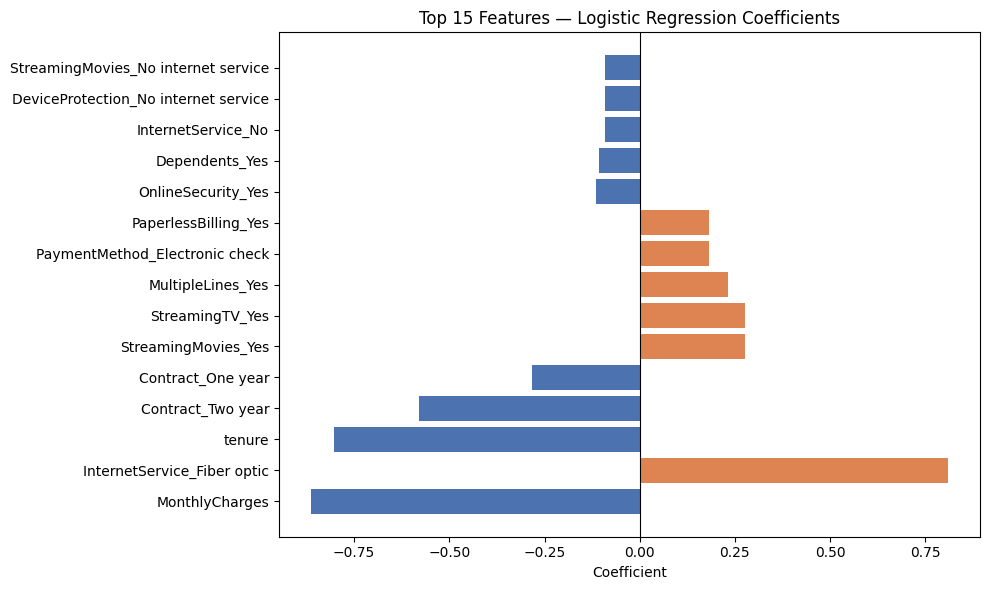

In [15]:
# ============================================================
# 9. FEATURE IMPORTANCE — LOGISTIC REGRESSION COEFFICIENTS
# ============================================================
#
# Logistic Regression coefficients indicate the direction and
# magnitude of each feature's influence on churn probability.
#
# Positive coefficient → increases churn probability
# Negative coefficient → decreases churn probability
#
# We use the default LR (not balanced) for interpretability,
# as coefficients are less distorted by class weighting.
# ============================================================

import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False).head(15)

colors = ["#DD8452" if c > 0 else "#4C72B0" for c in coef_df["Coefficient"]]

plt.figure(figsize=(10, 6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Top 15 Features — Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.savefig("../images/06_feature_importance_lr.png", dpi=150, bbox_inches="tight")
plt.show()

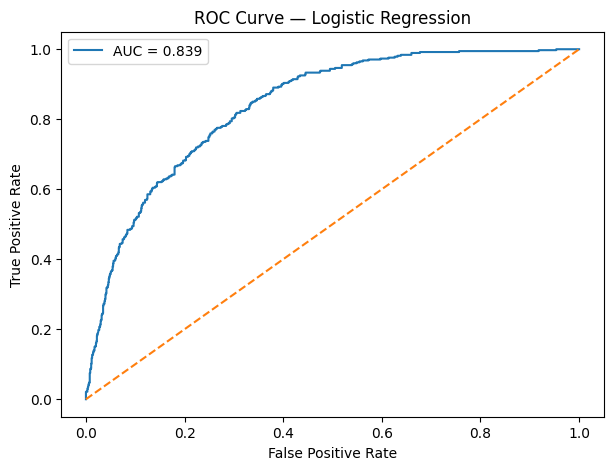

In [14]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_lr):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()

## Feature Importance — Key Findings

### Factors that increase churn risk
- **Fiber optic internet** is the strongest predictor of churn (coefficient: +0.81). 
  Customers on fiber optic plans are significantly more likely to leave, 
  possibly due to higher costs or unmet service expectations.
- **Electronic check payment** is associated with higher churn, consistent 
  with the EDA findings. Customers using automatic payment methods show 
  greater commitment to the service.
- **Paperless billing** customers churn more, likely due to higher digital 
  engagement and easier access to competitor comparisons.

### Factors that reduce churn risk
- **Tenure** is one of the strongest retention signals. The longer a customer 
  has been with the company, the less likely they are to leave.
- **Long-term contracts** (one year and two year) substantially reduce churn, 
  confirming that contract type is the most actionable retention lever.
- **Online Security** subscription reduces churn, suggesting that value-added 
  services increase customer stickiness.
- **Dependents** — customers with family commitments show lower churn rates.

### Business Recommendations
- Prioritize converting month-to-month customers to annual contracts.
- Investigate fiber optic service quality and pricing — the high churn rate 
  may indicate a gap between customer expectations and service delivery.
- Promote online security and tech support add-ons as retention tools.
- Design targeted retention campaigns for customers using electronic check 
  payment and paperless billing.